<a href="https://colab.research.google.com/github/sanjanapatilvv5/NNDL-Lab/blob/main/NNDL_1_15exp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0185
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7394e-04
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.5548e-04
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3435e-04
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


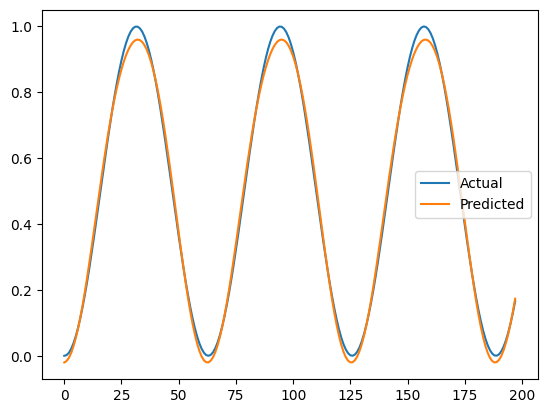

In [ ]:
#9 exp..........
 f# Install required libraries
!pip install numpy pandas matplotlib scikit-learn tensorflow

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Generate dummy time series data
data = np.sin(np.arange(0, 100, 0.1))

# Normalize datazuyv
scaler = MinMaxScaler()
data = scaler.fit_transform(data.reshape(-1,1))

# Create sequences
def create_dataset(data, time_step=10):
    X, Y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        Y.append(data[i+time_step, 0])
    return np.array(X), np.array(Y)

time_step = 10
X, Y = create_dataset(data, time_step)

# Reshape for RNN [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split data
train_size = int(len(X)*0.8)
X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

# Build RNN model
model = Sequential()
model.add(SimpleRNN(50, return_sequences=False, input_shape=(time_step,1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Train model
model.fit(X_train, Y_train, epochs=5, batch_size=32)

# Predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Plot results
plt.plot(Y_test, label='Actual')
plt.plot(test_predict, label='Predicted')
plt.legend()
plt.show()

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1300
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0329
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0260
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0223
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0179
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


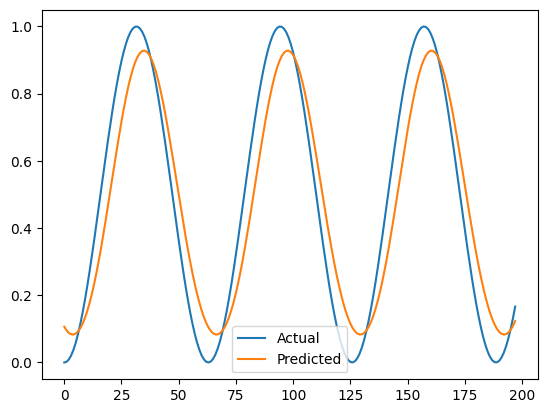

In [ ]:
#10.exp------------
# Install required libraries
!pip install numpy pandas matplotlib scikit-learn tensorflow

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Generate dummy data
data = np.sin(np.arange(0, 100, 0.1))

# Normalize
scaler = MinMaxScaler()
data = scaler.fit_transform(data.reshape(-1,1))

# Create dataset
def create_dataset(data, time_step=10):
    X, Y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        Y.append(data[i+time_step, 0])
    return np.array(X), np.array(Y)

time_step = 10
X, Y = create_dataset(data, time_step)

# Reshape
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split data
train_size = int(len(X)*0.8)
X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

# Build LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=False, input_shape=(time_step,1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Train
model.fit(X_train, Y_train, epochs=5, batch_size=32)

# Predict
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Plot
plt.plot(Y_test, label='Actual')
plt.plot(test_predict, label='Predicted')
plt.legend()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 455.5ms
Speed: 15.1ms preprocess, 455.5ms inference, 49.7ms postprocess per image at shape (1, 3, 640, 480)


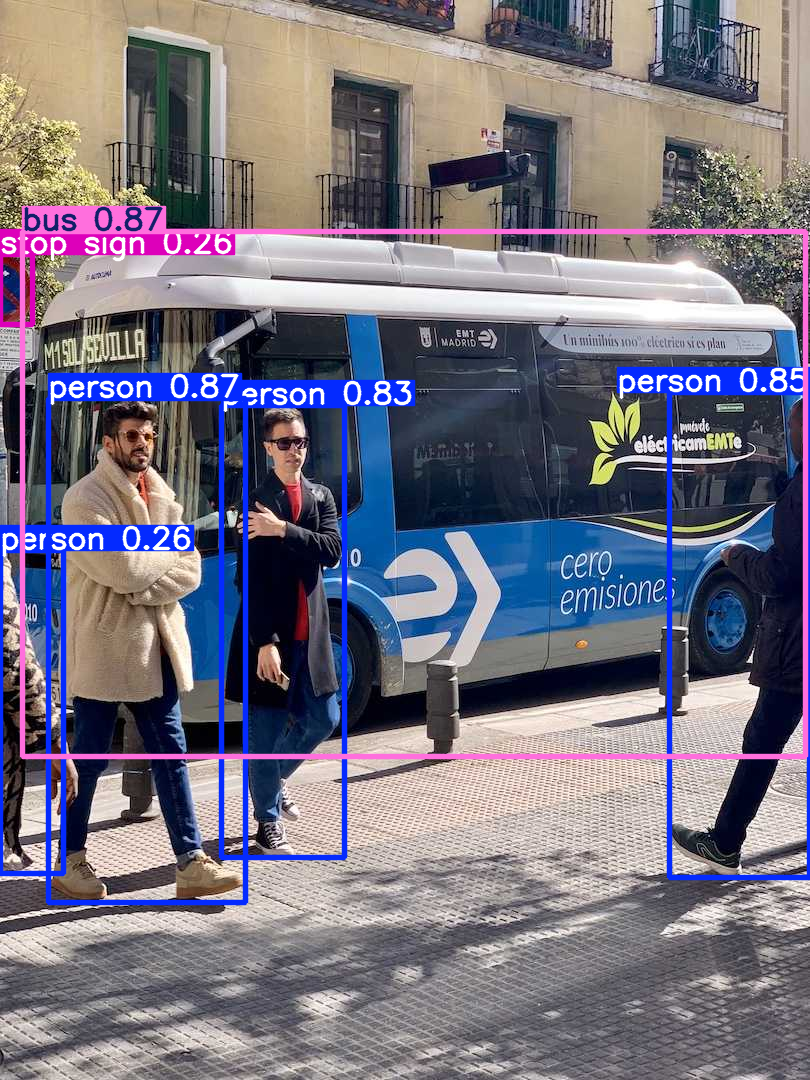

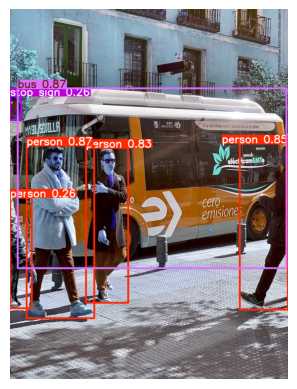

In [ ]:
#exp.11----
#Install YOLOv8
!pip install ultralytics

# Import libraries
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load pretrained YOLO model
model = YOLO("yolov8n.pt")   # nano model (fast)

# Load image
image_path = "https://ultralytics.com/images/bus.jpg"

# Perform detection
results = model(image_path)

# Show results (with bounding boxes)
results[0].show()

# If you want to plot manually
img = results[0].plot()

plt.imshow(img)
plt.axis('off')
plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 44ms/step - accuracy: 0.4116 - loss: 1.5994 - val_accuracy: 0.5427 - val_loss: 1.2721
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.5735 - loss: 1.2060 - val_accuracy: 0.5952 - val_loss: 1.1329
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.6311 - loss: 1.0516 - val_accuracy: 0.6441 - val_loss: 1.0074
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.6638 - loss: 0.9543 - val_accuracy: 0.6478 - val_loss: 1.0095
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.6871 - loss: 0.8905 - val_accuracy: 0.6818 - val_loss: 0.9280
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6818 - loss: 0.9280
Test Accuracy: 0.6818000078201294
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


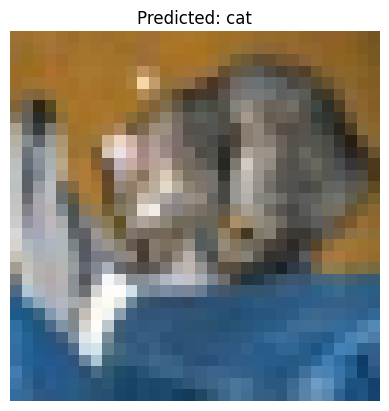

In [ ]:
#exp.12-----
# Install libraries
!pip install tensorflow matplotlib

# Import libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize data
x_train, x_test = x_train / 255.0, x_test / 255.0

# Class names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Build CNN model
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

# Compile model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Train model
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# Predict
predictions = model.predict(x_test)

# Display sample prediction
import numpy as np
plt.imshow(x_test[0])
plt.title("Predicted: " + class_names[np.argmax(predictions[0])])
plt.axis('off')
plt.show()

In [ ]:
#exp...13
# Install libraries
!pip install tensorflow

# Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
x_train, x_test = x_train/255.0, x_test/255.0

# Load pre-trained VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("Accuracy:", acc)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 632s 404ms/step - accuracy: 0.5232 - loss: 1.3675 - val_accuracy: 0.5637 - val_loss: 1.2514
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 625s 400ms/step - accuracy: 0.5834 - loss: 1.1886 - val_accuracy: 0.5789 - val_loss: 1.1993
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 628s 402ms/step - accuracy: 0.6047 - loss: 1.1321 - val_accuracy: 0.5927 - val_loss: 1.1632
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 671s 395ms/step - accuracy: 0.6181 - loss: 1.0941 - val_accuracy: 0.5972 - val_loss: 1.1531
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 657s 420ms/step - accuracy: 0.6269 - loss: 1.0611 - val_accuracy: 0.5999 - val_loss: 1.1392
313/313 ━━━━━━━━━━━━━━━━━━━━ 106s 337ms/step - accuracy: 0.5999 - loss: 1.1392
Accuracy: 0.5999000072479248


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 1.4519 | G Loss: 0.7147
Epoch 200 | D Loss: 5.7868 | G Loss: 0.0068
Epoch 400 | D Loss: 6.0187 | G Loss: 0.0034
Epoch 600 | D Loss: 6.1597 | G Loss: 0.0023
Epoch 800 | D Loss: 6.2726 | G Loss: 0.0017
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


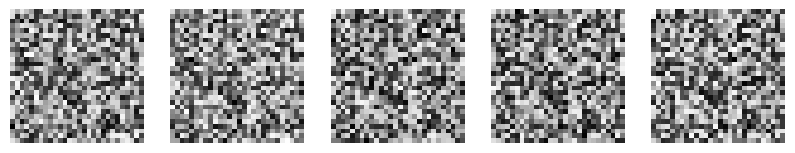

In [ ]:
#EXP-14..................
# Install libraries
!pip install tensorflow matplotlib

# Imports
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess dataset
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = (x_train.astype("float32") - 127.5) / 127.5
x_train = np.reshape(x_train, (x_train.shape[0], 784))

# Generator
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(128, activation='relu', input_dim=100),
        layers.Dense(784, activation='tanh')
    ])
    return model

# Discriminator
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Dense(128, activation='relu', input_dim=784),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# Build models
generator = build_generator()
discriminator = build_discriminator()

# Compile discriminator
discriminator.compile(optimizer='adam', loss='binary_crossentropy')

# GAN (generator + frozen discriminator)
discriminator.trainable = False
gan = tf.keras.Sequential([generator, discriminator])
gan.compile(optimizer='adam', loss='binary_crossentropy')

# Training loop
epochs = 1000
batch_size = 128

for epoch in range(epochs):
    # Train discriminator
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_images = x_train[idx]

    noise = np.random.normal(0, 1, (batch_size, 100))
    fake_images = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_images, np.ones((batch_size, 1)))
    d_loss_fake = discriminator.train_on_batch(fake_images, np.zeros((batch_size, 1)))

    # Train generator
    noise = np.random.normal(0, 1, (batch_size, 100))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

    # Print progress
    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D Loss: {0.5*(d_loss_real + d_loss_fake):.4f} | G Loss: {g_loss:.4f}")

# Generate and display images
noise = np.random.normal(0, 1, (5, 100))
gen_images = generator.predict(noise)

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(gen_images[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.show()

In [ ]:
#WXP-15.........
# Install libraries
!pip install transformers torch

# Import
from transformers import pipeline

# Load pre-trained BERT sentiment classifier
classifier = pipeline("sentiment-analysis")

# Input sentences
sentences = [
    "This product is amazing!",
    "Worst experience ever",
    "It is okay, not great"
]

# Predict
results = classifier(sentences)

# Print results
for sent, res in zip(sentences, results):
    print(f"Text: {sent}")
    print(f"Sentiment: {res['label']}, Score: {res['score']:.4f}")
    print()

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Text: This product is amazing!
Sentiment: POSITIVE, Score: 0.9999

Text: Worst experience ever
Sentiment: NEGATIVE, Score: 0.9998

Text: It is okay, not great
Sentiment: NEGATIVE, Score: 0.9395



In [ ]:
#EXP---2
# Install numpy (if not already installed)
!pip install numpy

# Import
import numpy as np

# -----------------------------
# 0D Tensor (Scalar)
# -----------------------------
x = np.array(8)
print("Scalar:", x)
print("Dimensions:", x.ndim)
print()

# -----------------------------
# 1D Tensor (Vector)
# -----------------------------
vec = np.array([10, 20, 30, 40, 50])
print("Vector:", vec)

# Loop through elements
for element in vec:
    print("Element:", element)

print()

# Vector with index
x = np.array([5, 10, 15])
for i, val in enumerate(x):
    print(f"Index {i}: {val}")

print("Dimensions:", x.ndim)
print("Shape:", x.shape)
print()

# -----------------------------
# 2D Tensor (Matrix)
# -----------------------------
mat = np.array([
    [3, 4, 7],
    [6, 8, 9],
    [10, 11, 12]
])

print("Matrix:\n", mat)
print("Dimensions:", mat.ndim)
print("Shape:", mat.shape)

Scalar: 8
Dimensions: 0

Vector: [10 20 30 40 50]
Element: 10
Element: 20
Element: 30
Element: 40
Element: 50

Index 0: 5
Index 1: 10
Index 2: 15
Dimensions: 1
Shape: (3,)

Matrix:
 [[ 3  4  7]
 [ 6  8  9]
 [10 11 12]]
Dimensions: 2
Shape: (3, 3)


In [ ]:
#EXP-3.............
# Install numpy
!pip install numpy

# Import numpy
import numpy as np

# Define vectors
v1 = np.array([10, 20, 30])
v2 = np.array([2, 4, 5])

# Vector operations
addition = v1 + v2
subtraction = v1 - v2
multiplication = v1 * v2
division = v1 / v2

# Print results
print("Vector 1:", v1)
print("Vector 2:", v2)

print("Addition:", addition)
print("Subtraction:", subtraction)
print("Multiplication:", multiplication)
print("Division:", division)

Vector 1: [10 20 30]
Vector 2: [2 4 5]
Addition: [12 24 35]
Subtraction: [ 8 16 25]
Multiplication: [ 20  80 150]
Division: [5. 5. 6.]


In [5]:
#EXP-4-------SLP
import numpy as np


def step_function(x):
    return 1 if x >= 0 else 0


inputs = np.array([[0,0],[0,1],[1,0],[1,1]])
targets = np.array([0, 0, 0, 1])


weights = np.zeros(2)
bias = 0
learning_rate = 0.1


for epoch in range(10):
    for i in range(len(inputs)):
        net_input = np.dot(inputs[i], weights) + bias
        output = step_function(net_input)
        error = targets[i] - output
        weights += learning_rate * error * inputs[i]
        bias += learning_rate * error


print("Final Weights:", weights)
print("Bias:", bias)
print("Outputs:")
for i in inputs:
    print(i, "->", step_function(np.dot(i, weights) + bias))

Final Weights: [0.2 0.1]
Bias: -0.20000000000000004
Outputs:
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


In [6]:
#EXP-4.....MLP
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


X = np.array([[0,0],[0,1],[1,0],[1,1]])


wh = np.random.rand(2, 3)
bh = np.random.rand(3)
wo = np.random.rand(3, 1)
bo = np.random.rand(1)


hidden_input = np.dot(X, wh) + bh
hidden_output = sigmoid(hidden_input)

final_input = np.dot(hidden_output, wo) + bo
final_output = sigmoid(final_input)

print("Final Output:")
print(final_output)

Final Output:
[[0.82354183]
 [0.84849199]
 [0.85403471]
 [0.86937406]]


K = 1, Accuracy = 0.9691
K = 2, Accuracy = 0.9627
K = 3, Accuracy = 0.9705
K = 4, Accuracy = 0.9682
K = 5, Accuracy = 0.9688
K = 6, Accuracy = 0.9677
K = 7, Accuracy = 0.9694
K = 8, Accuracy = 0.9670
K = 9, Accuracy = 0.9659
K = 10, Accuracy = 0.9665


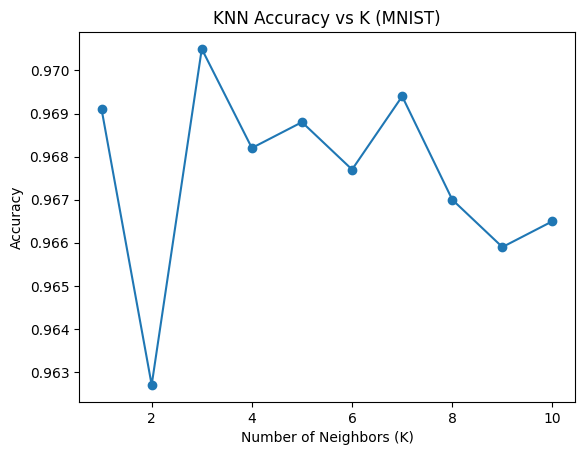

In [7]:
#EXP-5-----
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Flatten 28x28 images into 1D vectors
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

k_values = range(1, 11)
accuracy_list = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_list.append(acc)

    print(f"K = {k}, Accuracy = {acc:.4f}")

plt.figure()
plt.plot(k_values, accuracy_list, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K (MNIST)")
plt.show()

In [8]:
#EXP-6-------

!pip install tensorflow


import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_features = 10000
maxlen = 100

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)


x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)


model = Sequential()
model.add(Embedding(max_features, 32, input_length=maxlen))
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))


model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)


loss, accuracy = model.evaluate(x_test, y_test)


print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - accuracy: 0.7400 - loss: 0.5092 - val_accuracy: 0.8146 - val_loss: 0.4129
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.8752 - loss: 0.3084 - val_accuracy: 0.8108 - val_loss: 0.4124
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.9156 - loss: 0.2226 - val_accuracy: 0.8296 - val_loss: 0.4069
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9559 - loss: 0.1250 - val_accuracy: 0.8284 - val_loss: 0.4965
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9797 - loss: 0.0676 - val_accuracy: 0.8190 - val_loss: 0.5964
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8199 - loss: 0.5939
Test Loss: 0.5939193367958069
Test Accuracy: 0.819920003414154


In [9]:
#EXP-7-------
!pip install tensorflow scikit-learn

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)

# Generate normal data (100 samples, 10 timesteps, 1 feature)
normal_data = np.random.normal(loc=0, scale=1, size=(100, 10, 1))

# Scale data
scaler = MinMaxScaler()
normal_data = scaler.fit_transform(normal_data.reshape(-1, 1)).reshape(100, 10, 1)

# Model
inputs = Input(shape=(10, 1))
encoded = LSTM(32, activation='relu')(inputs)
decoded = RepeatVector(10)(encoded)
decoded = LSTM(32, activation='relu', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(1))(decoded)

autoencoder = Model(inputs, decoded)

# Compile
autoencoder.compile(optimizer='adam', loss='mse')

# Train
autoencoder.fit(normal_data, normal_data,
                epochs=20,
                batch_size=32,
                validation_split=0.2)

# Reconstruction
reconstructed = autoencoder.predict(normal_data)

# Compute reconstruction error (MSE)
mse = np.mean(np.power(normal_data - reconstructed, 2), axis=(1,2))

# Threshold
threshold = np.mean(mse) + 2*np.std(mse)
print("Threshold:", threshold)

# Detect anomalies
anomalies = mse > threshold
print("Number of anomalies detected:", np.sum(anomalies))

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 383ms/step - loss: 0.2297 - val_loss: 0.2366
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.2169 - val_loss: 0.2238
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.2052 - val_loss: 0.2119
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.1941 - val_loss: 0.2002
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.1834 - val_loss: 0.1888
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1728 - val_loss: 0.1771
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1617 - val_loss: 0.1644
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.1495 - val_loss: 0.1504
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.1363 - val_loss: 0.1349
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.1214 - val_loss: 0.1175
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.1050 - val_loss: 0.0983
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0871 - val_loss: 0.0775


Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 384ms/step - bbox_output_loss: 0.1690 - class_output_accuracy: 0.5400 - class_output_loss: 2.8468 - loss: 3.2427
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 532ms/step - bbox_output_loss: 0.0863 - class_output_accuracy: 0.5000 - class_output_loss: 0.7890 - loss: 0.9003
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 354ms/step - bbox_output_loss: 0.0793 - class_output_accuracy: 0.5400 - class_output_loss: 0.6858 - loss: 0.7650
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 437ms/step - bbox_output_loss: 0.0760 - class_output_accuracy: 0.6600 - class_output_loss: 0.6761 - loss: 0.7575
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 744ms/step - bbox_output_loss: 0.0765 - class_output_accuracy: 0.5600 - class_output_loss: 0.6533 - loss: 0.7322


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Car Probability: [[0.5355297]]
Predicted Bounding Box: [[0.4924016  0.5130618  0.51413095 0.45368013]]


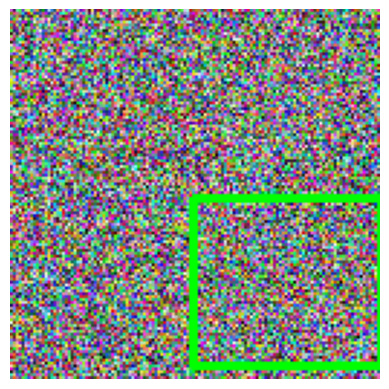

In [10]:
#EXP------8
# Install libraries
!pip install tensorflow opencv-python matplotlib

# Imports
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

# Dummy dataset (images + labels)
X = np.random.rand(100, 128, 128, 3)

# Class label (car present or not: 0/1)
y_class = np.random.randint(0, 2, (100, 1))

# Bounding box: [x, y, width, height]
y_bbox = np.random.rand(100, 4)

# Input layer
input_layer = layers.Input(shape=(128, 128, 3))

# CNN layers
x = layers.Conv2D(32, (3, 3), activation="relu")(input_layer)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation="relu")(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

# Outputs
class_output = layers.Dense(1, activation="sigmoid", name="class_output")(x)
bbox_output = layers.Dense(4, activation="sigmoid", name="bbox_output")(x)

# Model
model = models.Model(inputs=input_layer, outputs=[class_output, bbox_output])

# Compile
model.compile(
    optimizer="adam",
    loss={
        "class_output": "binary_crossentropy",
        "bbox_output": "mse"
    },
    metrics={
        "class_output": "accuracy"
    }
)

# Train
model.fit(
    X,
    {"class_output": y_class, "bbox_output": y_bbox},
    epochs=5,
    batch_size=16
)

# Test prediction
test_img = np.random.rand(1, 128, 128, 3)
pred_class, pred_bbox = model.predict(test_img)

print("Car Probability:", pred_class)
print("Predicted Bounding Box:", pred_bbox)

# Draw bounding box
img = (test_img[0] * 255).astype(np.uint8)

h, w, _ = img.shape
x1 = int(pred_bbox[0][0] * w)
y1 = int(pred_bbox[0][1] * h)
bw = int(pred_bbox[0][2] * w)
bh = int(pred_bbox[0][3] * h)

cv2.rectangle(img, (x1, y1), (x1 + bw, y1 + bh), (0, 255, 0), 2)

plt.imshow(img)
plt.axis("off")
plt.show()